# Torch Batteries Example: FrozenLake A2C with Local Tracking

This notebook trains an on-policy Advantage Actor-Critic (A2C) agent on Gymnasium's deterministic `FrozenLake-v1` environment. The agent gathers experience by interacting with the environment; a DataPack-managed lazy dataset supplies a fresh on-policy rollout for every training epoch and another evaluates the greedy policy, while `Battery` performs the policy and value update. `ExperimentTrackingCallback` records the run with `LocalTracker`.

[DataPack guide](https://michalszc.github.io/torch-batteries/guides/data-pack/) · [Training guide](https://michalszc.github.io/torch-batteries/guides/training/) · [Callbacks reference](https://michalszc.github.io/torch-batteries/reference/callbacks/) · [Tracking reference](https://michalszc.github.io/torch-batteries/reference/tracking/)

## 0. Prerequisites

Use Python 3.12 or newer. The next cell installs the library and example dependencies in a fresh notebook environment. FrozenLake is generated locally by Gymnasium, so no dataset download or external tracking account is needed.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup and reproducibility

The environment has 16 discrete states and four actions. We use the deterministic map for a short, reproducible demonstration. Each state is encoded as a one-hot vector.

In [1]:
from io import BytesIO
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display as ipython_display
from PIL import Image as PILImage
import torch
import torch_batteries
import yaml
from torch import nn
from torch.distributions import Categorical
from torch.nn import functional as F
from torch.utils.data import IterableDataset

from torch_batteries import (Battery, DataContext, DataLoaderConfig, DataPack, DatasetBundle, Event, EventContext, StepOutput, charge)
from torch_batteries.callbacks import ExperimentTrackingCallback
from torch_batteries.tracking import LocalTracker, Run

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"torch-batteries version: {torch_batteries.__version__}")
print(f"Gymnasium version: {gym.__version__}")

torch-batteries version: 1.0.0
Gymnasium version: 1.3.0


## 2. Define the actor and critic

One network encodes the state, then separate actor and critic heads produce action logits and a value estimate. The charged training step recomputes action probabilities for the latest rollout and combines policy gradient, value, and entropy losses.

In [2]:
class FrozenLakeA2C(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(16, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh())
        self.actor = nn.Linear(64, 4)
        self.critic = nn.Linear(64, 1)

    def forward(self, states):
        hidden = self.shared(states)
        return self.actor(hidden), self.critic(hidden).squeeze(-1)

    @charge(Event.TRAIN_STEP)
    def train_step(self, context: EventContext):
        states, actions, returns, advantages, success_rate = context["batch"]
        logits, values = self(states)
        distribution = Categorical(logits=logits)
        actor_loss = -(distribution.log_prob(actions) * advantages).mean()
        critic_loss = F.mse_loss(values, returns)
        loss = actor_loss + 0.5 * critic_loss - 0.01 * distribution.entropy().mean()
        return StepOutput(loss=loss, metrics={"success_rate": success_rate})

    @charge(Event.TEST_STEP)
    def test_step(self, context: EventContext):
        episode_rewards = context["batch"]
        success_rate = episode_rewards.float().mean()
        return StepOutput(loss=1 - success_rate, metrics={"success_rate": success_rate})


model = FrozenLakeA2C()

## 3. Collect a fresh on-policy rollout each epoch

A sized `IterableDataset` collects episodes only when the DataPack training loader is iterated. A separate test dataset later runs fresh greedy-policy episodes and stores one episode for the GIF. `SETUP_DATA` provides that dataset, and `CONFIGURE_DATALOADER` keeps its full rollout as one batch. It yields one full-rollout batch per epoch, and `Battery` makes one optimizer step on that batch. Every transition comes from Gymnasium and was sampled by the current actor; no rollout is reused after the policy changes. Potential-based reward shaping supplies a learning signal on the sparse-reward map, while the success metric and final evaluation use the environment's original reward.

In [3]:
class OnPolicyRollout(IterableDataset):
    def __init__(self, model, *, episodes=32, gamma=0.99):
        self.model = model
        self.episodes = episodes
        self.gamma = gamma
        self.epoch = 0

    def __len__(self):
        return 1  # One full-rollout batch is produced per epoch.

    @staticmethod
    def potential(state):
        row, col = divmod(state, 4)
        return -(abs(3 - row) + abs(3 - col)) / 6

    def __iter__(self):
        self.epoch += 1
        states, actions, returns, advantages = [], [], [], []
        successes = 0
        was_training = self.model.training
        self.model.eval()
        environment = gym.make("FrozenLake-v1", is_slippery=False)
        for episode in range(self.episodes):
            state, _ = environment.reset(seed=SEED + self.epoch * 1000 + episode)
            trajectory = []
            for _ in range(100):
                state_tensor = F.one_hot(torch.tensor(state), num_classes=16).float().unsqueeze(0)
                with torch.no_grad():
                    logits, value = self.model(state_tensor)
                    action = Categorical(logits=logits).sample().item()
                next_state, reward, terminated, truncated, _ = environment.step(action)
                shaped_reward = reward + self.gamma * self.potential(next_state) - self.potential(state)
                trajectory.append((state_tensor.squeeze(0), action, shaped_reward, value.item()))
                state = next_state
                if terminated or truncated:
                    successes += int(reward > 0)
                    break
            discounted_return = 0.0
            episode_returns = []
            for _, _, reward, _ in reversed(trajectory):
                discounted_return = reward + self.gamma * discounted_return
                episode_returns.append(discounted_return)
            for (state_tensor, action, _, value), target_return in zip(trajectory, reversed(episode_returns)):
                states.append(state_tensor)
                actions.append(action)
                returns.append(target_return)
                advantages.append(target_return - value)
        environment.close()
        self.model.train(was_training)
        yield (
            torch.stack(states),
            torch.tensor(actions, dtype=torch.long),
            torch.tensor(returns, dtype=torch.float32),
            torch.tensor(advantages, dtype=torch.float32),
            torch.tensor(successes / self.episodes, dtype=torch.float32),
        )


class GreedyEvaluation(IterableDataset):
    def __init__(self, model, episodes=100):
        self.model = model
        self.episodes = episodes
        self.frames = []

    def __len__(self):
        return 1  # One batch containing all evaluation episode rewards.

    def __iter__(self):
        environment = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
        rewards = []
        self.frames = []
        was_training = self.model.training
        self.model.eval()
        for episode in range(self.episodes):
            state, _ = environment.reset(seed=SEED + 100_000 + episode)
            if episode == 0:
                self.frames.append(environment.render())
            for _ in range(100):
                state_tensor = F.one_hot(torch.tensor(state), num_classes=16).float().unsqueeze(0)
                with torch.no_grad():
                    logits, _ = self.model(state_tensor)
                    action = logits.argmax(dim=-1).item()
                state, reward, terminated, truncated, _ = environment.step(action)
                if episode == 0:
                    self.frames.append(environment.render())
                if terminated or truncated:
                    rewards.append(reward)
                    break
        environment.close()
        self.model.train(was_training)
        yield torch.tensor(rewards, dtype=torch.float32)

    def display_episode(self):
        images = [PILImage.fromarray(frame).resize((320, 320)) for frame in self.frames]
        animation = BytesIO()
        images[0].save(animation, format="GIF", save_all=True, append_images=images[1:], duration=350, loop=0)
        ipython_display.display(ipython_display.Image(data=animation.getvalue()))


class FrozenLakeDataPack(DataPack):
    def __init__(self, model):
        self.rollout = OnPolicyRollout(model)
        self.evaluation = GreedyEvaluation(model)

    @charge(Event.SETUP_DATA)
    def setup(self, context: DataContext):
        if context["stage"] == "test":
            return DatasetBundle(test=self.evaluation)
        return DatasetBundle(train=self.rollout)

    @charge(Event.CONFIGURE_DATALOADER)
    def configure(self, context: DataContext):
        return DataLoaderConfig(batch_size=None)


data_pack = FrozenLakeDataPack(model)
print(f"Fresh episodes per epoch: {data_pack.rollout.episodes}")

Fresh episodes per epoch: 32


## 4. Train with LocalTracker

The DataPack-managed on-policy dataset builds each batch lazily. The same `ExperimentTrackingCallback` works with `LocalTracker` as with other `ExperimentTracker` implementations. Each run gets a new `version_N` directory under `data/my_experiments/frozenlake_a2c`, with `hparams.yaml`, `metrics.csv`, and `summary.yaml`. The CSV has one row per epoch and dynamically named metric columns such as `train/loss` and `train/success_rate`. The YAML summary keeps only the latest scalar value for each metric. This local backend records numbers and configuration but does not save model artifacts.

In [4]:
tracker = LocalTracker("frozenlake_a2c", save_dir=Path("data/my_experiments"))
tracking = ExperimentTrackingCallback(
    tracker,
    run=Run(name="frozenlake-a2c", config={"environment": "FrozenLake-v1", "episodes_per_epoch": data_pack.rollout.episodes, "gamma": data_pack.rollout.gamma, "seed": SEED}),
)
battery = Battery(
    model, device="cpu", optimizer=torch.optim.Adam(model.parameters(), lr=3e-3),
    callbacks=[tracking], data_pack=data_pack,
)
history = battery.train(epochs=80, verbose=1)
print(f"Epochs: {history['epochs_completed']}; optimizer steps: {history['optimizer_steps']}")
print(f"Last rollout success rate: {history['train_metrics']['success_rate'][-1]:.1%}")
print(f"Run directory: {tracker.run_dir}")

Epochs: 80; optimizer steps: 80
Last rollout success rate: 100.0%
Run directory: data/my_experiments/frozenlake_a2c/version_6


## 5. Inspect the local experiment

`metrics.csv` has one row per completed epoch, with each metric in its own column. The `summary.yaml` file contains the latest metric values and run totals, while `hparams.yaml` records the model and optimizer configuration.

 epoch  train/loss  train/success_rate
     1    0.474806             0.00000
     2    0.378266             0.03125
     3    0.120887             0.00000
     4   -0.072244             0.03125
     5   -0.161353             0.00000
Recorded epochs: 80; metric columns: ['epoch', 'train/loss', 'train/success_rate']
Latest saved success rate: 100.0%
Saved files: ['hparams.yaml', 'metrics.csv', 'summary.yaml']


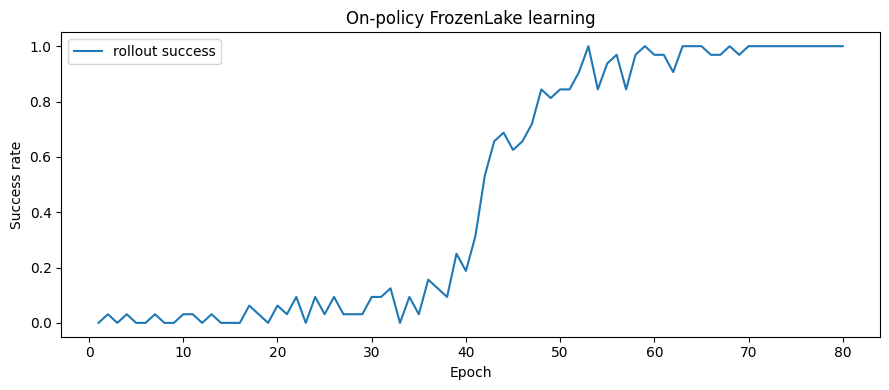

In [5]:
metrics = pd.read_csv(tracker.run_dir / "metrics.csv")
with (tracker.run_dir / "summary.yaml").open(encoding="utf-8") as stream:
    summary = yaml.safe_load(stream)
print(metrics.head().to_string(index=False))
print(f"Recorded epochs: {len(metrics)}; metric columns: {list(metrics.columns)}")
print(f"Latest saved success rate: {summary['train_metrics']['success_rate']:.1%}")
print("Saved files:", sorted(path.name for path in tracker.run_dir.iterdir()))

figure, ax = plt.subplots(figsize=(9, 4))
ax.plot(metrics["epoch"], metrics["train/success_rate"], label="rollout success")
ax.set(xlabel="Epoch", ylabel="Success rate", ylim=(-0.05, 1.05), title="On-policy FrozenLake learning")
ax.legend()
figure.tight_layout()
plt.show()

## 6. Evaluate and display the learned policy

`battery.test()` asks the same DataPack for its evaluation dataset. The dataset runs fresh greedy-policy episodes, and the charged test step reports their success rate using Gymnasium's original reward. The DataPack also captures and displays one episode as an animated GIF, following the CartPole example.

Greedy policy success: 100% across 100 episodes


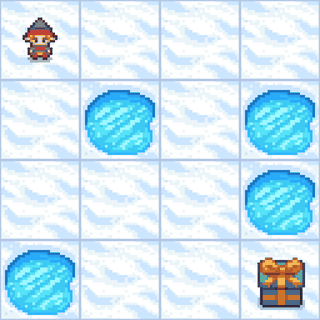

In [6]:
test_result = battery.test(verbose=1)
print(f"Greedy policy success: {test_result['test_metrics']['success_rate']:.0%} across {data_pack.evaluation.episodes} episodes")
data_pack.evaluation.display_episode()